# Exploratory Data Analysis

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

Data dictionary
- `Z:*` - process parameters, fixed per experiment (feed start/end day, feed rates, pH/temp start-end-shift, stirring, DO, experiment duration).
- `W:*` - time-varying control/input (temperature, pH, glucose/glutamine feed rate). Length matches the number of sampled days.
- `X:*` - time-varying process observations (VCD, Glc, Gln, Ammonia, Lactate, Lysed cell fraction)
- `Y:Titer` - target, measured only once at the end of the experiment.

Useful resources to help understand dataset:
1. https://www.sciencedirect.com/science/article/pii/S1369703X23000086
2. https://datahow.ch/model-based-upstream-process-optimization/

In [2]:
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

DATA_DIR = "../data"
train_data = pd.read_csv(f"{DATA_DIR}/datahow_interview_train_data.csv")
train_targets = pd.read_csv(f"{DATA_DIR}/datahow_interview_train_targets.csv")
test_data = pd.read_csv(f"{DATA_DIR}/datahow_interview_test_data.csv")
test_targets_template = pd.read_csv(
    f"{DATA_DIR}/datahow_interview_test_targets-TEMPLATE.csv"
)

display(train_data.head())

print("train_data:", train_data.shape)
print("train_targets:", train_targets.shape)
print("test_data:", test_data.shape)
print("test_targets_template:", test_targets_template.shape)

,RowID,Exp,Time[day],Z:FeedStart,Z:FeedEnd,Z:FeedRateGlc,Z:FeedRateGln,Z:phStart,Z:phEnd,Z:phShift,Z:tempStart,Z:tempEnd,Z:tempShift,Z:Stir,Z:DO,Z:ExpDuration,W:temp,W:pH,W:FeedGlc,W:FeedGln,X:VCD,X:Glc,X:Gln,X:Amm,X:Lac,X:Lysed
0,0,Exp 1,0,2.0,10.0,5.656566,6.818182,6.808081,6.479798,9.0,37.282828,35.070707,13.0,224.242424,43.383838,10.0,37.282828,6.808081,0.000000,0.000000,1.682644,2.853045,6.005418,0.100000,0.100000,0.000000
1,1,Exp 1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.282828,6.808081,0.000000,0.000000,3.617721,2.290199,3.598475,0.324724,1.348831,0.002831
2,2,Exp 1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.282828,6.808081,5.656566,6.818182,6.431879,0.752652,0.481756,0.687781,3.065268,0.000884
3,3,Exp 1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.282828,6.808081,5.656566,6.818182,10.279057,4.276583,2.516062,0.972871,4.196027,0.000000
4,4,Exp 1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.282828,6.808081,5.656566,6.818182,14.888965,7.350100,3.471558,1.322927,4.845310,0.000218


train_data: (990, 26)
train_targets: (100, 4)
test_data: (300, 26)
test_targets_template: (20, 4)


## 1. Data structure

### 1.1 Training Set

In [3]:
n_exp_train = train_data["Exp"].nunique()
n_exp_test = test_data["Exp"].nunique()
duration_train = train_data.groupby("Exp")["Time[day]"].max()

Z_COLS = [c for c in train_data.columns if c.startswith("Z:")]
W_COLS = [c for c in train_data.columns if c.startswith("W:")]
X_COLS = [c for c in train_data.columns if c.startswith("X:")]

print(f"Train: {n_exp_train}")
print(f"Actual test: {n_exp_test}")
print("\nDistribution of experiment duration (days) in train set:")
print(duration_train.value_counts().sort_index())

Train: 100
Actual test: 20

Distribution of experiment duration (days) in train set:
Time[day]
7     30
8     20
9     20
10    20
14    10
Name: count, dtype: int64


**The characteristics of the raw data show several highlights**:

1. `Z:*` columns are only populated on day 0. These values are global constants for each experiment. The target `Y:Titer` is recorded once per experiment.

2. **Ragged sequence lengths** <br>
   Bioprocesses do not have a uniform end-point. It runs vary from 7 up to 14 days (ragged). Classical ML regressors and standard sequence deep learning models expect static, uniform-length inputs, therefore we have to either transform or compress these ragged sequences.
   
3. **Scarce data** <br>
   There are only 100 training experiments. This is highly restrictive. Thus using deep learning (LSTMs, GRUs, Transformers) may overfit heavily on $N \approx 100$. This strongly motivates classical feature engineering paired with low-parameter models (non-neural-network-based model).
   
4. **Severe multicollinearity** <br>
   The features are highly collinear:
   - **Autocorrelation:** Consecutive days of process observations (e.g. VCD) are highly correlated.
   - **Cross-variable correlation:** Nutrient feed controls (`W:`) directly dictate cell growth and metabolite observation profiles (`X:`).

5. **Inconsistency:** <br> Parameter mismatches within the dataset. For example, in the first experiment, final Temp on day 0 (35.07070707) does not match the temperature on last day (37.28282828). In fact, they are supposed to be the same value. 


In [4]:
# Check the temperature / pH mismatches

day0 = train_data[train_data["Time[day]"] == 0].set_index("Exp")
last = train_data.loc[train_data.groupby("Exp")["Time[day]"].idxmax()].set_index("Exp")


def check_shift_param(w_col: str, z_prefix: str) -> pd.DataFrame:
    """Check a start/end/shift of temperature and pH data between Z: and W: column
    for first and last day
    """
    check = pd.DataFrame(
        {
            f"Z:{z_prefix}Start": day0[f"Z:{z_prefix}Start"],
            f"day0_{w_col}": day0[w_col],
            f"Z:{z_prefix}End": day0[f"Z:{z_prefix}End"],
            f"last_day_{w_col}": last[w_col],
            f"Z:{z_prefix}Shift": day0[f"Z:{z_prefix}Shift"],
            "last_day": last["Time[day]"],
        }
    )
    check["start_matches"] = np.isclose(
        check[f"Z:{z_prefix}Start"], check[f"day0_{w_col}"]
    )
    check["end_matches"] = np.isclose(
        check[f"Z:{z_prefix}End"], check[f"last_day_{w_col}"]
    )
    check["shift_by_last_day"] = check[f"Z:{z_prefix}Shift"] <= check["last_day"]
    return check


temp_check = check_shift_param("W:temp", "temp")
ph_check = check_shift_param("W:pH", "ph")

print("\nCheck the temperature mismatches across all 100 experiments:")
print(
    "day0 W:temp == Z:tempStart:",
    temp_check["start_matches"].value_counts().to_dict(),
)
print(
    "last-day W:temp == Z:tempEnd:",
    temp_check["end_matches"].value_counts().to_dict(),
)
# print("\nExperiments where last-day temp does NOT match Z:tempEnd:")
# display(temp_check[~temp_check["end_matches"]])

print("\nCheck the pH mismatches across all 100 experiments:")
print(
    "day0 W:pH == Z:phStart:",
    ph_check["start_matches"].value_counts().to_dict(),
)
print(
    "last-day W:pH == Z:phEnd:",
    ph_check["end_matches"].value_counts().to_dict(),
)
# print("\nExperiments where last-day pH does NOT match Z:phEnd:")
# display(ph_check[~ph_check["end_matches"]])


Check the temperature mismatches across all 100 experiments:
day0 W:temp == Z:tempStart: {True: 100}
last-day W:temp == Z:tempEnd: {False: 56, True: 44}

Check the pH mismatches across all 100 experiments:
day0 W:pH == Z:phStart: {True: 100}
last-day W:pH == Z:phEnd: {False: 59, True: 41}


### 1.2 Test Set

Let's have a look at characteristics of the test set:


Comparison of Z process parameters (Train vs Test):


,Train Min,Train Max,Train Mean,Test Min,Test Max,Test Mean
Parameter,,,,,,
Z:FeedStart,1.000000,3.000000,2.0,1.000000,3.000000,2.0
Z:FeedEnd,9.000000,13.000000,11.0,9.000000,13.000000,11.0
Z:FeedRateGlc,2.020202,5.979798,4.0,2.105263,5.894737,4.0
Z:FeedRateGln,6.010101,7.989899,7.0,6.052632,7.947368,7.0
Z:phStart,6.505051,7.494949,7.0,6.526316,7.473684,7.0
Z:phEnd,6.005051,6.994949,6.5,6.026316,6.973684,6.5
Z:phShift,6.000000,14.000000,10.0,6.000000,14.000000,10.0
Z:tempStart,36.010101,37.989899,37.0,36.052632,37.947368,37.0
Z:tempEnd,35.010101,36.989899,36.0,35.052632,36.947368,36.0



Missing values in test W and X columns:
None (0 missing)


,Train Mean,Test Mean,Train Max,Test Max
Variable,,,,
W:temp,36.883461,36.637193,37.989899,37.947368
W:pH,6.941144,6.847719,7.494949,7.473684
W:FeedGlc,2.963942,2.439298,5.979798,5.894737
W:FeedGln,5.250168,4.180351,7.989899,7.947368
X:VCD,13.425586,18.417464,61.242464,53.792282
X:Glc,7.210130,9.276855,44.011310,56.760437
X:Gln,7.406499,8.867710,62.089637,56.621750
X:Amm,2.023753,3.257307,13.744255,13.528379
X:Lac,3.271055,3.252037,8.078131,8.351408


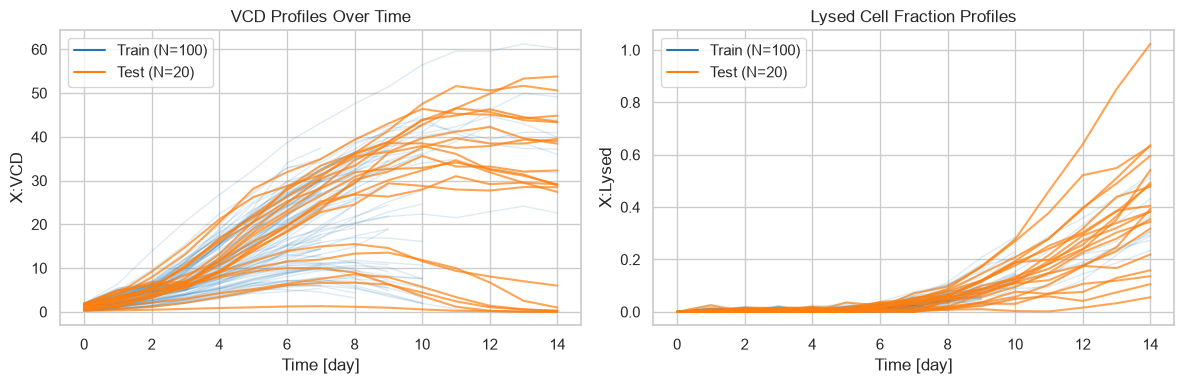

In [5]:
# Check process parameters (Z) distribution: Train vs Test at Day 0
train_day0 = train_data[train_data["Time[day]"] == 0].set_index("Exp")
test_day0 = test_data[test_data["Time[day]"] == 0].set_index("Exp")

z_comparison = []
for z in Z_COLS:
    z_comparison.append(
        {
            "Parameter": z,
            "Train Min": train_day0[z].min(),
            "Train Max": train_day0[z].max(),
            "Train Mean": train_day0[z].mean(),
            "Test Min": test_day0[z].min(),
            "Test Max": test_day0[z].max(),
            "Test Mean": test_day0[z].mean(),
        }
    )

z_comp_df = pd.DataFrame(z_comparison).set_index("Parameter")
print("\nComparison of Z process parameters (Train vs Test):")
display(z_comp_df)

# Check for missing values in test set W and X columns
missing_wx = test_data[W_COLS + X_COLS].isna().sum()
print("\nMissing values in test W and X columns:")
print(missing_wx[missing_wx > 0] if (missing_wx > 0).any() else "None (0 missing)")

# Compare distribution of observations (X) and controls (W)
wx_comp = []
for col in W_COLS + X_COLS:
    wx_comp.append(
        {
            "Variable": col,
            "Train Mean": train_data[col].mean(),
            "Test Mean": test_data[col].mean(),
            "Train Max": train_data[col].max(),
            "Test Max": test_data[col].max(),
        }
    )
display(pd.DataFrame(wx_comp).set_index("Variable"))

# Visualize trajectory comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for _, grp in train_data.groupby("Exp"):
    axes[0].plot(
        grp["Time[day]"], grp["X:VCD"], color="tab:blue", alpha=0.15, linewidth=1
    )
for _, grp in test_data.groupby("Exp"):
    axes[0].plot(
        grp["Time[day]"], grp["X:VCD"], color="tab:orange", alpha=0.7, linewidth=1.5
    )
axes[0].plot([], [], color="tab:blue", label="Train (N=100)")
axes[0].plot([], [], color="tab:orange", label="Test (N=20)")
axes[0].set_xlabel("Time [day]")
axes[0].set_ylabel("X:VCD")
axes[0].set_title("VCD Profiles Over Time")
axes[0].legend()

for _, grp in train_data.groupby("Exp"):
    axes[1].plot(
        grp["Time[day]"], grp["X:Lysed"], color="tab:blue", alpha=0.15, linewidth=1
    )
for _, grp in test_data.groupby("Exp"):
    axes[1].plot(
        grp["Time[day]"], grp["X:Lysed"], color="tab:orange", alpha=0.7, linewidth=1.5
    )
axes[1].plot([], [], color="tab:blue", label="Train (N=100)")
axes[1].plot([], [], color="tab:orange", label="Test (N=20)")
axes[1].set_xlabel("Time [day]")
axes[1].set_ylabel("X:Lysed")
axes[1].set_title("Lysed Cell Fraction Profiles")
axes[1].legend()

plt.tight_layout()
plt.show()

The result above shows that:

- Test set sample size of 20 experiments for the full 14 days.
- The range of **process parameters (`Z:*`):** (feed start/end, pH/temp shifts, stirring, DO) in the test set fall completely within the domain of the training design space.
- Cumulative summary features (e.g. `VCD_auc`, `Lysed_final`, `FeedGlc_auc`) exhibit systematically higher magnitudes in the test set.
- Unregularized linear models (like MLR on all 67 features) suffer from severe extrapolation artifacts when exposed to 14-day test AUC magnitudes, predicting physically impossible negative titers. 
- Tree-based models (Gradient Boosting, Random Forest, XGBoost) and constrained linear models (MLR Top 5) remain robust against this mismatch.

## 2. Feature Engineering and Data Processing 

We use the following feature engineering techniques to process the data from long format (day-level) to one row per experiment because we want to turn the ragged time-series problem into a standard tabular regression problem.

**1. Data cleaning**
1. Clip physically-impossible negative concentrations (`X:VCD`, `X:Glc`, `X:Gln`, `X:Amm`, `X:Lac`, `X:Lysed`) to 0.
2. Re-check no missing values remain in `W:*`/`X:*` after cleaning.
3. Leave `Z:*` NaNs on day > 0

**2. Feature engineering** (see implementation below)
1. Static features: all `Z:*` scalars (day-0 row).
2. Time-series summaries per `W:*`/`X:*` column: final value, max, mean, AUC (cumulative exposure/production), linear slope.
3. Domain-informed features:
   - `VCD_growth_rate`: overall specific growth rate $$\ln(VCD_{final}/VCD_{initial})/\text{duration}$$
   - `VCD_time_to_peak`: day at which VCD peaks. This marks the onset of the stationary/death phase.

**3. Multicollinearity handling**

Rather than manually dropping correlated engineered features, we should rely on collinearity-robust models (e.g. PLS, regularized Ridge, tree ensembles), which are justified by correlation heatmap in the section 3.

**4. Cross-validation strategy**

K-fold splits by `n_days` (duration) as duration is the single strongest driver of titer.

In [6]:
# Validation / integrity checks
issues = []

# Confirm that Exp keys match between data and targets
train_exps, target_exps = set(train_data["Exp"]), set(train_targets["Exp"])
if train_exps != target_exps:
    issues.append(
        f"Exp mismatch between train_data and train_targets: {train_exps ^ target_exps}"
    )

# Confirm that Time[day] is a complete
for exp, group in train_data.groupby("Exp"):
    days = sorted(group["Time[day]"].tolist())
    expected = list(range(int(days[-1]) + 1))
    if days != expected:
        issues.append(f"{exp}: non-contiguous day index {days}")

# Confirm that Z:* populated on day 0 only, for every experiment
z_day0 = train_data.loc[train_data["Time[day]"] == 0, Z_COLS].isna().any(axis=1)
z_other = train_data.loc[train_data["Time[day]"] != 0, Z_COLS].notna().any(axis=1)
if z_day0.any() or z_other.any():
    issues.append("Z:* columns violate the day-0-only pattern for some rows")

# Make sure that there is no duplicate (Exp, Time[day]) rows
dup = train_data.duplicated(subset=["Exp", "Time[day]"]).sum()
if dup:
    issues.append(f"{dup} duplicate (Exp, Time[day]) rows found")

print(
    "Validation issues found:"
    if issues
    else "All validation checks passed - no issues found."
)

for issue in issues:
    print(" -", issue)

All validation checks passed - no issues found.


In [7]:
def clean_timeseries(df: pd.DataFrame) -> pd.DataFrame:
    """Clip physically-impossible negative concentrations/counts to 0 (plan step B)."""
    df = df.copy()
    neg_counts = (df[X_COLS] < 0).sum()
    if neg_counts.any():
        print(
            "Clipping negative values found in:",
            neg_counts[neg_counts > 0].to_dict(),
        )
    df[X_COLS] = df[X_COLS].clip(lower=0)
    return df

In [8]:
def featurize_timeseries(group: pd.DataFrame, cols: list[str]) -> dict:
    """Summarize one experiment's time-series columns into scalar features."""
    t = group["Time[day]"].to_numpy(dtype=float)
    feats = {}
    for c in cols:
        y = group[c].to_numpy(dtype=float)
        name = c.split(":", 1)[1]
        feats[f"{name}_final"] = y[-1]
        feats[f"{name}_auc"] = np.trapezoid(y, t) if len(t) > 1 else 0.0
        slope = np.polyfit(t, y, 1)[0] if len(t) > 1 else 0.0
        feats[f"{name}_slope"] = slope

    # domain-informed features (plan step C.3), derived from VCD growth dynamics
    vcd = group["X:VCD"].to_numpy(dtype=float)
    vcd_initial = vcd[0] if vcd[0] > 0 else 1e-6
    duration = t[-1] if t[-1] > 0 else 1.0
    feats["VCD_growth_rate"] = np.log(max(vcd[-1], 1e-6) / vcd_initial) / duration
    feats["VCD_time_to_peak"] = t[np.argmax(vcd)]
    return feats

In [9]:
def build_experiment_table(df: pd.DataFrame) -> pd.DataFrame:
    """Collapse long (Exp, day) data into one row per experiment."""
    df = clean_timeseries(df)
    rows = []
    for exp, group in df.groupby("Exp", sort=False):
        group = group.sort_values("Time[day]")
        n_days = group["Time[day]"].max()
        z_row = group.loc[group["Time[day]"] == 0, Z_COLS].iloc[0].to_dict()
        ts_feats = featurize_timeseries(group, W_COLS + X_COLS)
        rows.append(
            {
                "Exp": exp,
                "n_days": n_days,
                **z_row,
                **ts_feats,
                # whether the scheduled Z:*Shift day was actually reached,
                # so Z:*End is realized rather than just a target setpoint
                "temp_shift_reached": z_row["Z:tempShift"] <= n_days,
                "ph_shift_reached": z_row["Z:phShift"] <= n_days,
            }
        )
    return pd.DataFrame(rows).set_index("Exp")

In [10]:
train_exp = build_experiment_table(train_data)
test_exp = build_experiment_table(test_data)

train_exp = train_exp.join(train_targets.set_index("Exp")["Y:Titer"])

print("train_exp:", train_exp.shape)
print("test_exp:", test_exp.shape)

feature_cols = [c for c in train_exp.columns if c not in ("Y:Titer", "n_days")]
print(f"Final features ({len(feature_cols)}):")
print(*feature_cols, sep="\n")

train_exp.head()

train_exp: (100, 49)
test_exp: (20, 48)
Final features (47):
Z:FeedStart
Z:FeedEnd
Z:FeedRateGlc
Z:FeedRateGln
Z:phStart
Z:phEnd
Z:phShift
Z:tempStart
Z:tempEnd
Z:tempShift
Z:Stir
Z:DO
Z:ExpDuration
temp_final
temp_auc
temp_slope
pH_final
pH_auc
pH_slope
FeedGlc_final
FeedGlc_auc
FeedGlc_slope
FeedGln_final
FeedGln_auc
FeedGln_slope
VCD_final
VCD_auc
VCD_slope
Glc_final
Glc_auc
Glc_slope
Gln_final
Gln_auc
Gln_slope
Amm_final
Amm_auc
Amm_slope
Lac_final
Lac_auc
Lac_slope
Lysed_final
Lysed_auc
Lysed_slope
VCD_growth_rate
VCD_time_to_peak
temp_shift_reached
ph_shift_reached


,n_days,Z:FeedStart,Z:FeedEnd,Z:FeedRateGlc,Z:FeedRateGln,Z:phStart,Z:phEnd,Z:phShift,Z:tempStart,Z:tempEnd,Z:tempShift,Z:Stir,Z:DO,Z:ExpDuration,temp_final,temp_auc,temp_slope,pH_final,pH_auc,pH_slope,FeedGlc_final,FeedGlc_auc,FeedGlc_slope,FeedGln_final,FeedGln_auc,FeedGln_slope,VCD_final,VCD_auc,VCD_slope,Glc_final,Glc_auc,Glc_slope,Gln_final,Gln_auc,Gln_slope,Amm_final,Amm_auc,Amm_slope,Lac_final,Lac_auc,Lac_slope,Lysed_final,Lysed_auc,Lysed_slope,VCD_growth_rate,VCD_time_to_peak,temp_shift_reached,ph_shift_reached,Y:Titer
Exp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Exp 1,10,2.0,10.0,5.656566,6.818182,6.808081,6.479798,9.0,37.282828,35.070707,13.0,224.242424,43.383838,10.0,37.282828,372.828283,1.086378e-15,6.479798,67.588384,-2.685950e-02,0.000000,45.252525,0.205693,0.000000,54.545455,0.247934,36.988184,198.803887,3.950632,14.657896,84.052505,1.501787,0.073529,15.653790,-0.485023,4.063493,20.594577,0.439514,4.828035,40.956149,0.387198,0.282538,0.510602,0.022485,0.309023,10.0,False,True,2550.097032
Exp 2,10,1.0,12.0,5.696970,6.979798,6.606061,6.207071,8.0,37.121212,35.595960,10.0,155.555556,67.121212,10.0,35.595960,370.449495,-6.932966e-02,6.207071,65.063131,-4.352617e-02,5.696970,54.121212,0.258953,6.979798,66.308081,0.317264,3.199769,74.750902,0.424282,44.011310,217.843153,4.154249,38.988539,189.183768,3.566544,6.847133,28.383367,0.715316,7.120991,52.328712,0.701286,0.230921,0.393049,0.018635,0.062388,6.0,True,True,1278.058508
Exp 3,9,3.0,11.0,3.030303,7.242424,6.585859,6.803030,8.0,37.565657,35.818182,8.0,163.636364,64.595960,9.0,35.818182,335.469697,-1.694521e-01,6.803030,59.598485,2.105908e-02,3.030303,19.696970,0.385675,7.242424,47.075758,0.921763,18.878325,79.912784,1.828174,9.393444,55.105478,0.606615,17.708428,74.765963,1.995879,4.178718,12.939670,0.432324,5.566270,30.101523,0.612346,0.039230,0.102039,0.003967,0.259017,9.0,True,True,1162.646534
Exp 4,9,2.0,12.0,4.484848,6.838384,6.717172,6.651515,12.0,37.787879,35.535354,12.0,194.949495,63.080808,9.0,37.787879,340.090909,0.000000e+00,6.717172,60.454545,-1.052223e-16,4.484848,33.636364,0.434894,6.838384,51.287879,0.663116,10.807090,64.793778,1.265115,23.473798,97.977054,2.478694,28.320916,115.392979,2.994667,4.735391,16.425461,0.541590,6.797757,33.968210,0.743174,0.089675,0.115842,0.006892,0.245739,8.0,False,False,1012.535606
Exp 5,8,3.0,11.0,5.090909,6.232323,7.424242,6.469697,13.0,36.979798,35.858586,8.0,222.222222,38.333333,8.0,35.858586,295.277778,-7.474747e-02,7.424242,59.393939,-2.487397e-16,5.090909,28.000000,0.763636,6.232323,34.277778,0.934848,27.690723,100.495435,3.331973,12.257980,48.691336,1.100149,0.000000,7.123416,-0.395722,2.637526,9.186463,0.322818,5.229935,30.108121,0.604946,0.043197,0.096457,0.004464,0.334355,8.0,True,False,1132.710237


## 3. Visualizations of Training Set

### 3.1 Target distribution

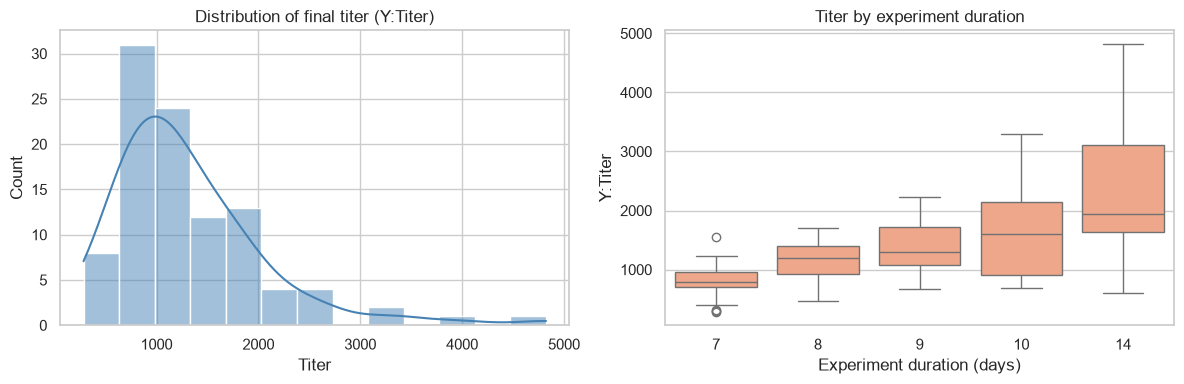

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_exp["Y:Titer"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of final titer (Y:Titer)")
axes[0].set_xlabel("Titer")

sns.boxplot(data=train_exp, x="n_days", y="Y:Titer", ax=axes[1], color="lightsalmon")
axes[1].set_title("Titer by experiment duration")
axes[1].set_xlabel("Experiment duration (days)")
plt.tight_layout()
plt.show()

In [12]:
print(train_exp["Y:Titer"].describe())
print("\nSkewness:", stats.skew(train_exp["Y:Titer"]))

count     100.000000
mean     1314.507270
std       753.087552
min       283.456126
25%       802.153610
50%      1147.678385
75%      1667.211098
max      4822.697067
Name: Y:Titer, dtype: float64

Skewness: 1.8801764674444819


Titer distribution is right-skewed (skew is around 1.9)

### 3.2 Process trajectories colored by final titer

Here we can reveal which dynamic behaviors (e.g., higher/faster VCD growth, lactate accumulation) are associated with higher titer.

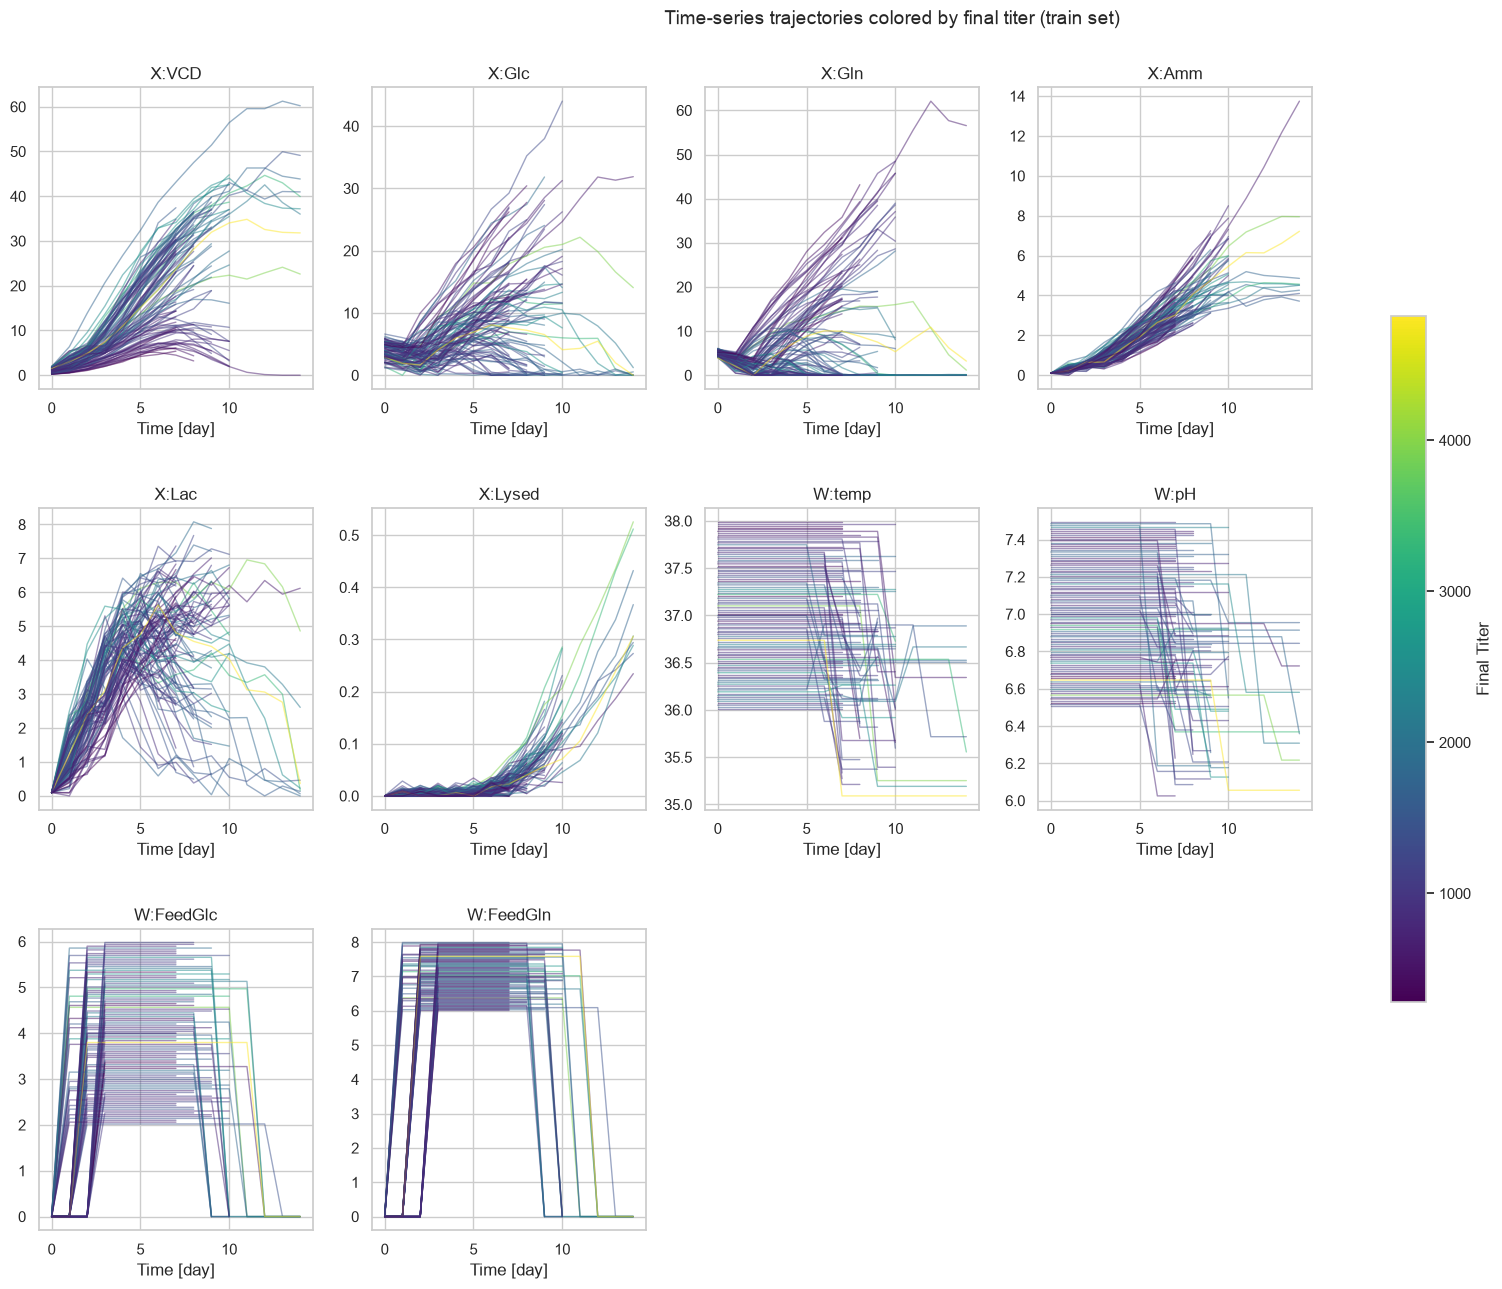

In [13]:
# Each line is one experiment; color encodes its final titer
plot_vars = X_COLS + ["W:temp", "W:pH", "W:FeedGlc", "W:FeedGln"]
norm = plt.Normalize(train_exp["Y:Titer"].min(), train_exp["Y:Titer"].max())
cmap = plt.get_cmap("viridis")

fig, axes = plt.subplots(3, 4, figsize=(18, 13), sharex=False)
axes = axes.ravel()
for ax, col in zip(axes, plot_vars):
    for exp, group in train_data.groupby("Exp", sort=False):
        group = group.sort_values("Time[day]")
        titer = train_targets.set_index("Exp").loc[exp, "Y:Titer"]
        ax.plot(
            group["Time[day]"],
            group[col],
            color=cmap(norm(titer)),
            alpha=0.5,
            linewidth=1,
        )
    ax.set_title(col)
    ax.set_xlabel("Time [day]")

for ax in axes[len(plot_vars) :]:
    ax.axis("off")

fig.tight_layout(h_pad=3.0, w_pad=2.0, rect=[0, 0, 0.92, 0.96])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=axes.tolist(), label="Final Titer", shrink=0.6)
fig.suptitle(
    "Time-series trajectories colored by final titer (train set)",
    y=0.99,
    fontsize=14,
)
plt.show()

### 3.3 Process parameter distributions and their relationship with titer

Here we look at the process parameter (Z) distribution and its important on the titer.


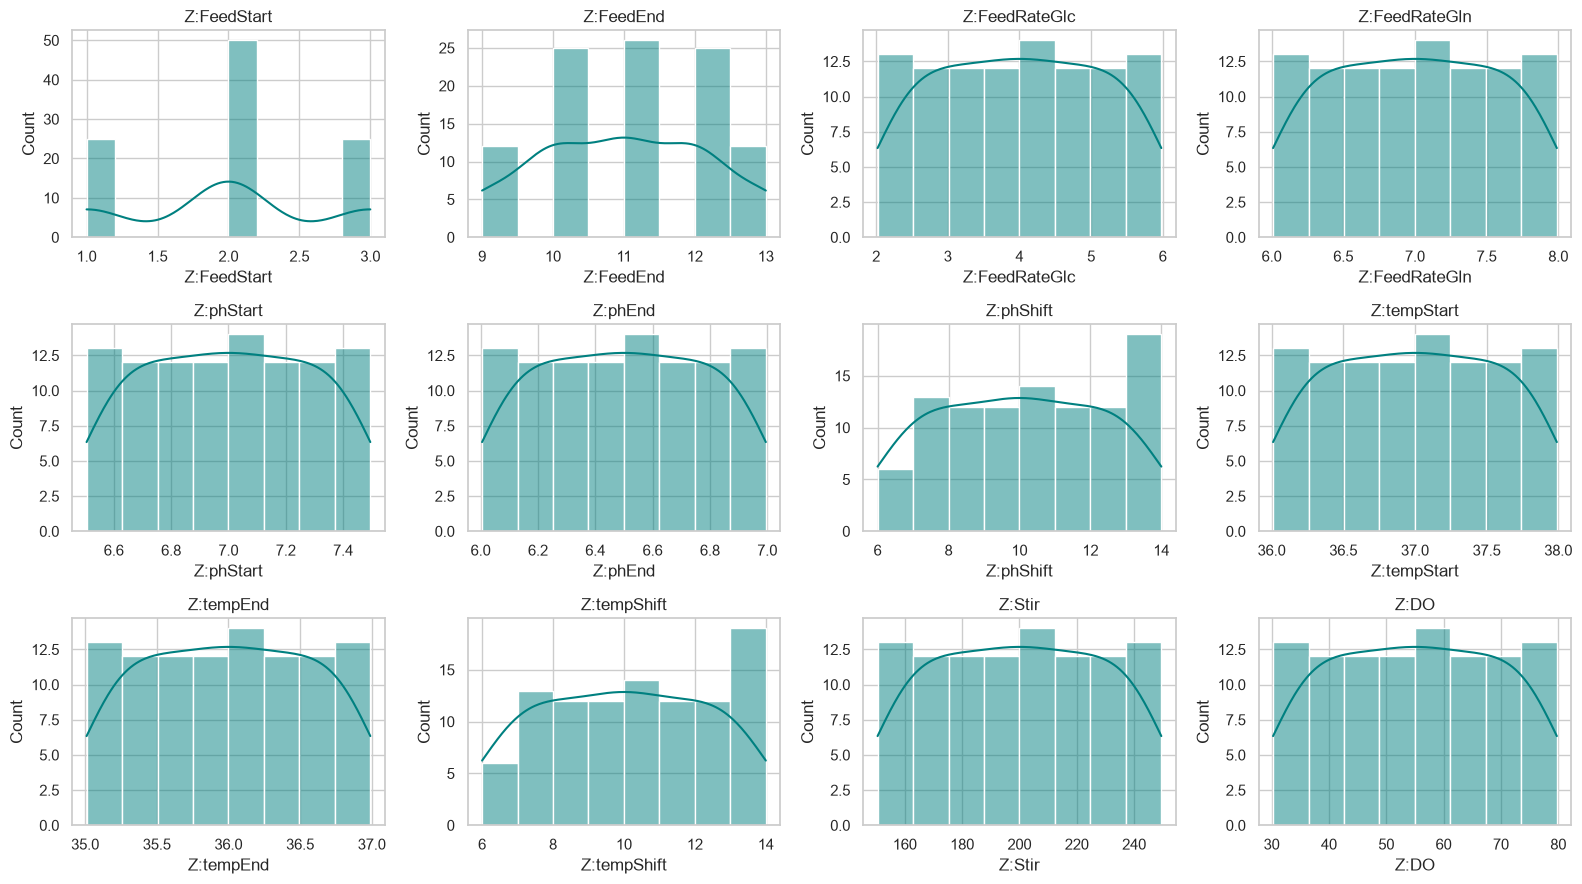

In [14]:
z_no_duration = [c for c in Z_COLS if c != "Z:ExpDuration"]
n_cols = 4
n_rows = int(np.ceil(len(z_no_duration) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.ravel()
for ax, col in zip(axes, z_no_duration):
    sns.histplot(train_exp[col], ax=ax, color="teal", kde=True)
    ax.set_title(col)
for ax in axes[len(z_no_duration) :]:
    ax.axis("off")
plt.tight_layout()
plt.show()

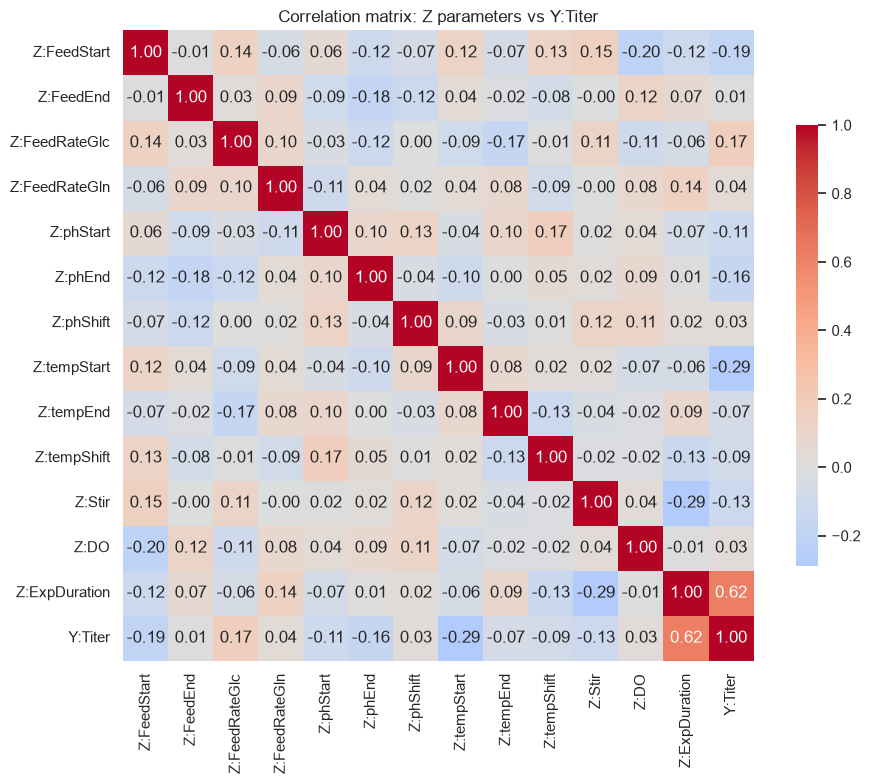

In [15]:
# Correlation heatmap: Z parameters (+ duration) vs each other and vs titer
corr_cols = Z_COLS + ["Y:Titer"]
corr = train_exp[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.7},
)
plt.title("Correlation matrix: Z parameters vs Y:Titer")
plt.tight_layout()
plt.show()

In [16]:
print("\nCorrelation of each Z parameter with Y:Titer, sorted by |r|:")
print(corr["Y:Titer"].drop("Y:Titer").sort_values(key=np.abs, ascending=False))


Correlation of each Z parameter with Y:Titer, sorted by |r|:
Z:ExpDuration    0.617820
Z:tempStart     -0.289348
Z:FeedStart     -0.185799
Z:FeedRateGlc    0.173562
Z:phEnd         -0.161592
Z:Stir          -0.132160
Z:phStart       -0.109523
Z:tempShift     -0.087102
Z:tempEnd       -0.066168
Z:FeedRateGln    0.041364
Z:phShift        0.030572
Z:DO             0.029056
Z:FeedEnd        0.006009
Name: Y:Titer, dtype: float64


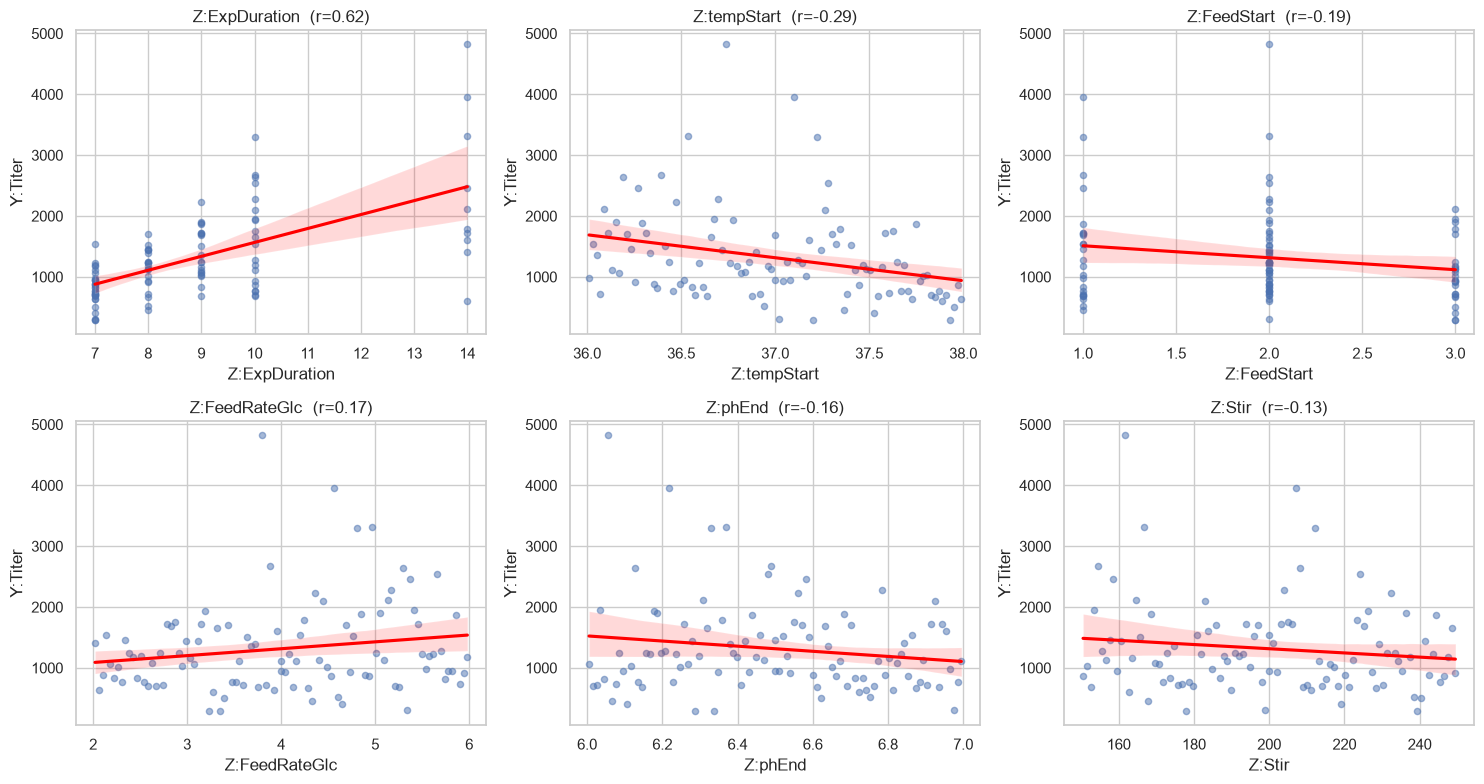

In [17]:
top_z = (
    corr["Y:Titer"]
    .drop("Y:Titer")
    .abs()
    .sort_values(ascending=False)
    .head(6)
    .index.tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.ravel(), top_z):
    sns.regplot(
        data=train_exp,
        x=col,
        y="Y:Titer",
        ax=ax,
        scatter_kws={"alpha": 0.5, "s": 20},
        line_kws={"color": "red"},
    )
    r = train_exp[[col, "Y:Titer"]].corr().iloc[0, 1]
    ax.set_title(f"{col}  (r={r:.2f})")

plt.tight_layout()
plt.show()

### 3.3 Process parameters for highest titer

We compare the top 15% highest-titer experiments ($\text{Titer} \ge 2119$ mg/L) against the remaining 85% using the non-parametric Mann-Whitney U test.

- **Feature Importance**: use a Random Forest (RF) regressor on static process parameters to calculate non-linear and interaction effects.
- **Recipe Comparison**: We extract the exact operating setpoints of the #1 highest-titer experiment (`Exp 93`, $4822.7$ mg/L) v.s. dataset averages.

PROCESS PARAMETER IMPACT ON TITER (RANKED BY STATISTICAL SIGNIFICANCE)


,Process Parameter,Top 15% Mean,Bottom 85% Mean,Delta,P-Value,Correlation (r),RF Importance (%)
0,Z:ExpDuration,11.200000,8.494118,2.705882,0.000002,0.617820,36.295863
1,Z:FeedRateGlc,4.740741,3.869281,0.871460,0.007075,0.173562,13.863577
2,Z:tempStart,36.657912,37.060368,-0.402456,0.013105,-0.289348,10.690694
3,Z:tempEnd,35.726599,36.048247,-0.321648,0.048922,-0.066168,10.317001
4,Z:phEnd,6.374747,6.522103,-0.147356,0.068080,-0.161592,5.310270
5,Z:phStart,6.912458,7.015449,-0.102991,0.199180,-0.109523,5.488082
6,Z:DO,50.690236,55.760547,-5.070311,0.206021,0.029056,5.916396
7,Z:Stir,192.861953,201.259655,-8.397703,0.310775,-0.132160,2.987567
8,Z:tempShift,10.333333,9.941176,0.392157,0.586088,-0.087102,1.915325
9,Z:phShift,9.733333,10.047059,-0.313725,0.644179,0.030572,1.327653



TOP PERFORMING RUN: Exp 93 (Titer = 4822.70 mg/L)


,Parameter,Best Exp Setting,Dataset Average
0,Z:FeedStart,2.000000,2.0
1,Z:FeedEnd,12.000000,11.0
2,Z:FeedRateGlc,3.797980,4.0
3,Z:FeedRateGln,7.585859,7.0
4,Z:phStart,6.646465,7.0
5,Z:phEnd,6.055556,6.5
6,Z:phShift,10.000000,10.0
7,Z:tempStart,36.737374,37.0
8,Z:tempEnd,35.090909,36.0
9,Z:tempShift,7.000000,10.0


/var/folders/h0/6hz9lfgx7zx0wp8y0jf80xzr0000gn/T/ipykernel_69177/3671161825.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/h0/6hz9lfgx7zx0wp8y0jf80xzr0000gn/T/ipykernel_69177/3671161825.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


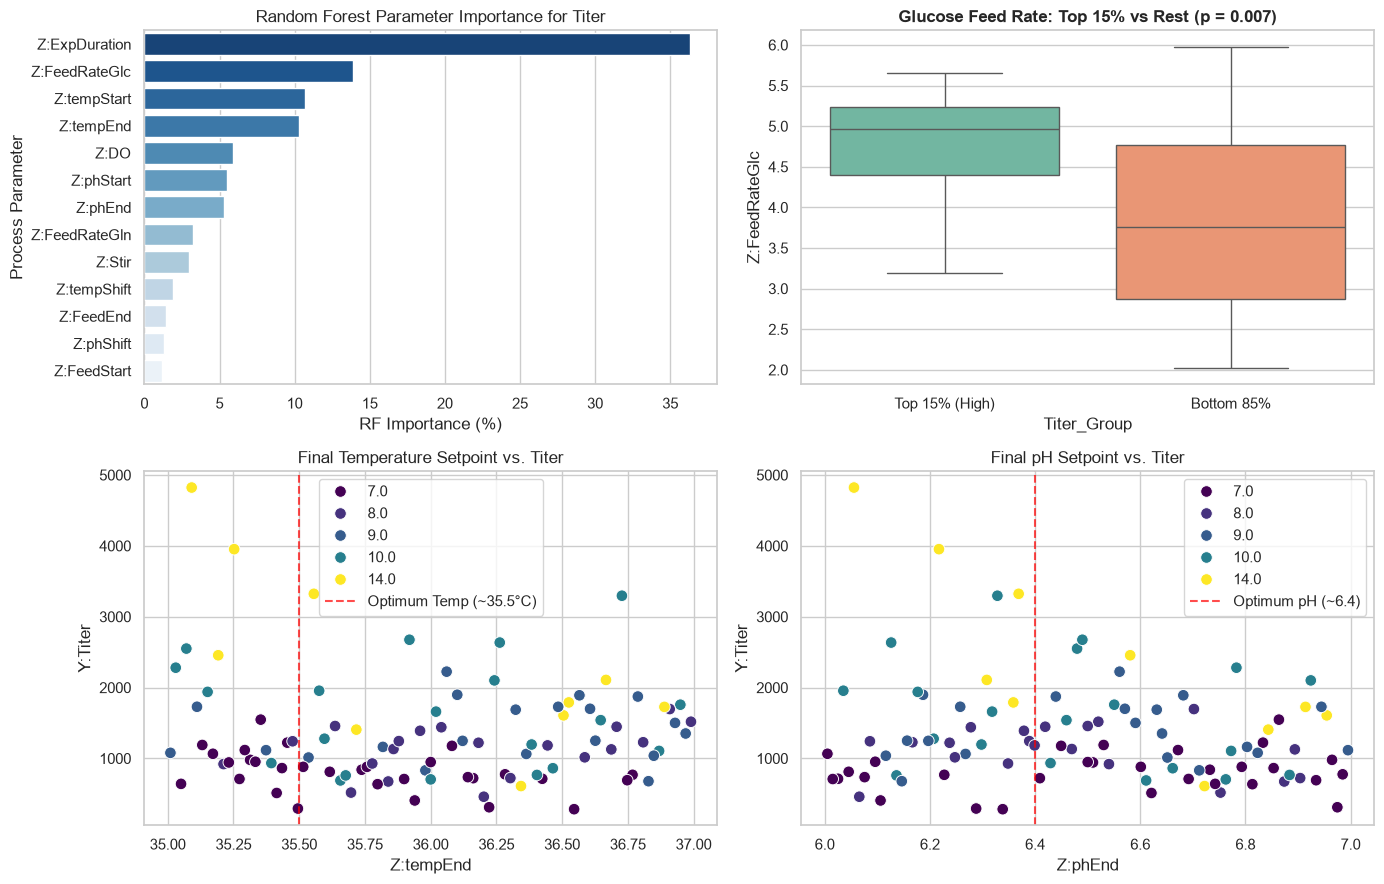

In [18]:
# 1. Statistical Ranking & Random Forest Importance
q85 = train_exp["Y:Titer"].quantile(0.85)
is_high_titer = train_exp["Y:Titer"] >= q85

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(train_exp[Z_COLS], train_exp["Y:Titer"])
rf_importance = pd.Series(rf.feature_importances_, index=Z_COLS)
correlations = train_exp[Z_COLS + ["Y:Titer"]].corr()["Y:Titer"].drop("Y:Titer")

records = []
for col in Z_COLS:
    high_group = train_exp.loc[is_high_titer, col]
    low_group = train_exp.loc[~is_high_titer, col]
    _, p_val = stats.mannwhitneyu(high_group, low_group)
    records.append(
        {
            "Process Parameter": col,
            "Top 15% Mean": high_group.mean(),
            "Bottom 85% Mean": low_group.mean(),
            "Delta": high_group.mean() - low_group.mean(),
            "P-Value": p_val,
            "Correlation (r)": correlations[col],
            "RF Importance (%)": rf_importance[col] * 100,
        }
    )

param_ranking = pd.DataFrame(records).sort_values("P-Value").reset_index(drop=True)
print("=" * 80)
print("PROCESS PARAMETER IMPACT ON TITER (RANKED BY STATISTICAL SIGNIFICANCE)")
print("=" * 80)
display(param_ranking)

# 2. Optimal Operating Recipe (Top Experiment vs Dataset Mean)
best_exp = train_exp.sort_values("Y:Titer", ascending=False).iloc[0]
print("\n" + "=" * 80)
print(f"TOP PERFORMING RUN: {best_exp.name} (Titer = {best_exp['Y:Titer']:.2f} mg/L)")
print("=" * 80)
recipe = pd.DataFrame(
    {
        "Parameter": Z_COLS,
        "Best Exp Setting": [best_exp[c] for c in Z_COLS],
        "Dataset Average": [train_exp[c].mean() for c in Z_COLS],
    }
)
display(recipe)

# 3. Diagnostic Visualizations
plot_df = train_exp.copy()
plot_df["Titer_Group"] = np.where(is_high_titer, "Top 15% (High)", "Bottom 85%")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Plot 1: Feature Importance
sns.barplot(
    data=param_ranking.sort_values("RF Importance (%)", ascending=False),
    x="RF Importance (%)",
    y="Process Parameter",
    palette="Blues_r",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Random Forest Parameter Importance for Titer")

# Plot 2: Glucose Feed Rate Distribution
sns.boxplot(
    data=plot_df, x="Titer_Group", y="Z:FeedRateGlc", palette="Set2", ax=axes[0, 1]
)
axes[0, 1].set_title(
    "Glucose Feed Rate: Top 15% vs Rest (p = 0.007)", fontweight="bold"
)

# Plot 3: Temperature End Setpoint vs Titer
sns.scatterplot(
    data=plot_df,
    x="Z:tempEnd",
    y="Y:Titer",
    hue="Z:ExpDuration",
    palette="viridis",
    s=70,
    ax=axes[1, 0],
)
axes[1, 0].set_title("Final Temperature Setpoint vs. Titer")
axes[1, 0].axvline(
    35.5, color="red", linestyle="--", alpha=0.7, label="Optimum Temp (~35.5°C)"
)
axes[1, 0].legend()

# Plot 4: Final pH Setpoint vs Titer
sns.scatterplot(
    data=plot_df,
    x="Z:phEnd",
    y="Y:Titer",
    hue="Z:ExpDuration",
    palette="viridis",
    s=70,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Final pH Setpoint vs. Titer")
axes[1, 1].axvline(
    6.4, color="red", linestyle="--", alpha=0.7, label="Optimum pH (~6.4)"
)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

Clearly, the result above shows that `Z:ExpDuation` is the most important parameter according to Random Forest prediction for titer. We could draw a rough conclusion that *the longer the duration, the higher the titer*.

### 3.4 Per-experiment characteristics: comparing all 100 experiments

Here we look at every experiment's full characteristic to see how experiments differ from one another and how those differences map to the final titer.

In [19]:
row_indices, col_indices = np.where(train_exp < 0)
summary = pd.DataFrame(
    {
        "Row": train_exp.index[row_indices],
        "Column": train_exp.columns[col_indices],
    }
)

# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     print(summary)

print(f"Number of distinct columns with negative values: {summary['Column'].nunique()}")
print(summary["Column"].value_counts())

Number of distinct columns with negative values: 10
Column
pH_slope           49
Gln_slope          49
temp_slope         46
Glc_slope          26
FeedGlc_slope       9
FeedGln_slope       9
Lac_slope           9
Lysed_slope         3
VCD_slope           1
VCD_growth_rate     1
Name: count, dtype: int64


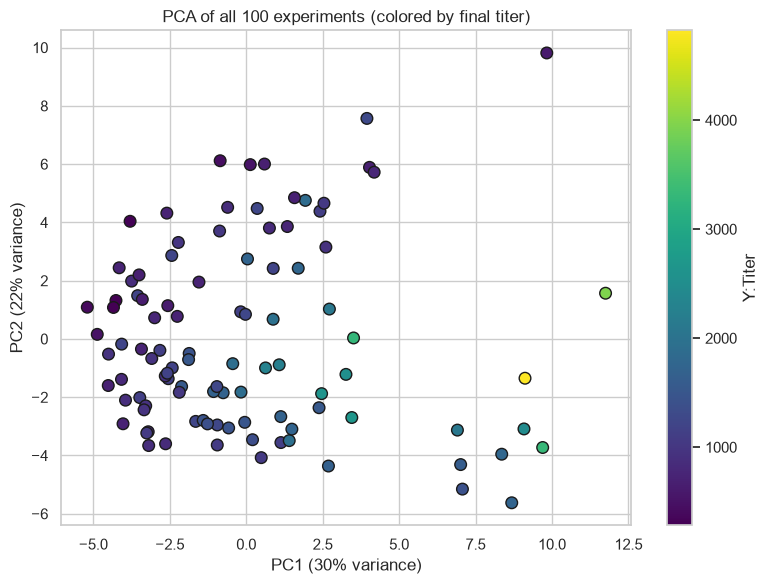

In [20]:
X_scaled = StandardScaler().fit_transform(train_exp[feature_cols])
pca = PCA(n_components=2, random_state=0)
pcs = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    pcs[:, 0],
    pcs[:, 1],
    c=train_exp["Y:Titer"],
    cmap="viridis",
    s=70,
    edgecolor="k",
)
plt.colorbar(sc, label="Y:Titer")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)")
plt.title("PCA of all 100 experiments (colored by final titer)")
plt.tight_layout()
plt.show()

### 3.5 Correlation Filtering


#### BEFORE Correlation Filtering

Here we start with engineered time-series features and their relationship with titer.

Number of features before filtering: 47


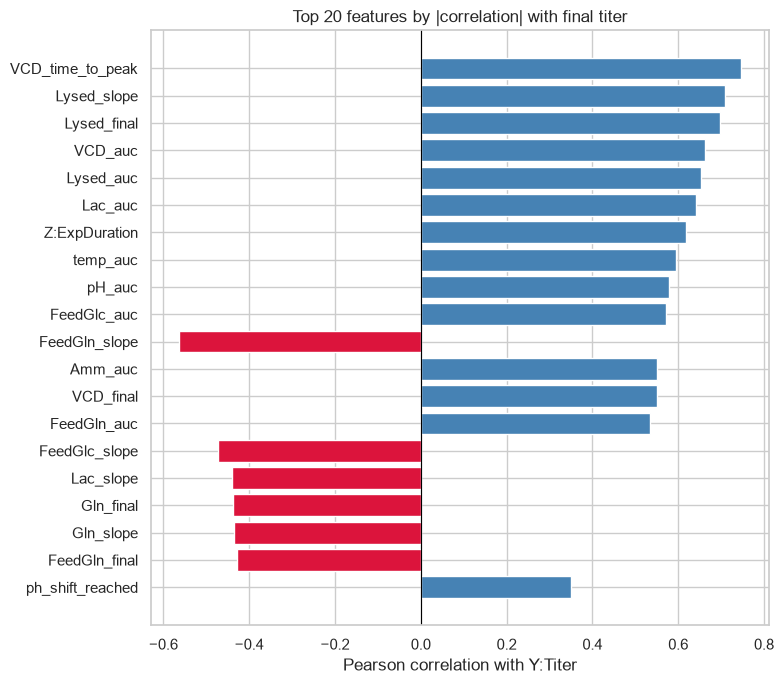

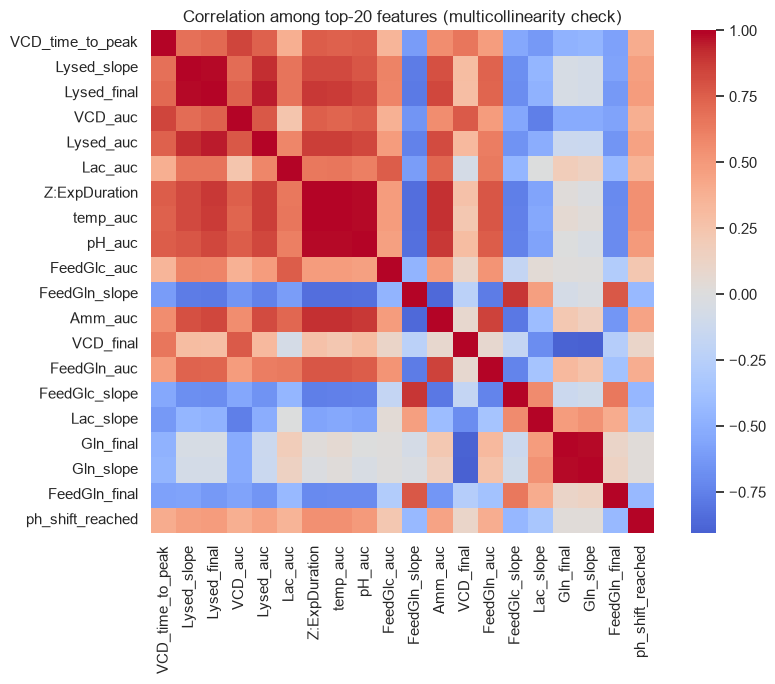

In [21]:
feature_cols = [c for c in train_exp.columns if c not in ("Y:Titer", "n_days")]
print("Number of features before filtering:", len(feature_cols))
all_corr = train_exp[feature_cols + ["Y:Titer"]].corr()["Y:Titer"].drop("Y:Titer")
top20 = all_corr.abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 7))
colors = ["crimson" if all_corr[f] < 0 else "steelblue" for f in top20.index]
plt.barh(top20.index[::-1], all_corr[top20.index][::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Pearson correlation with Y:Titer")
plt.title("Top 20 features by |correlation| with final titer")
plt.tight_layout()
plt.show()

# multicollinearity check among top features (typical for Z process settings
# and derived stats)
plt.figure(figsize=(9, 7))
sns.heatmap(train_exp[top20.index].corr(), cmap="coolwarm", center=0, square=True)
plt.title("Correlation among top-20 features (multicollinearity check)")
plt.tight_layout()
plt.show()

#### AFTER Correlation Filtering

Now we filter out a feature from each redundant feature pair.

Total features evaluated: 47
Candidates with |r_target| >= 0.25: 29
Retained non-redundant features (|r_pair| < 0.85): 18
--- Retained Features ---
                    r_target  abs_r_target
VCD_time_to_peak    0.746116      0.746116
Lysed_slope         0.707956      0.707956
VCD_auc             0.661282      0.661282
Lac_auc             0.640767      0.640767
Z:ExpDuration       0.617820      0.617820
FeedGlc_auc         0.572434      0.572434
FeedGln_slope      -0.563131      0.563131
VCD_final           0.549665      0.549665
FeedGln_auc         0.534694      0.534694
Lac_slope          -0.439737      0.439737
FeedGln_final      -0.427952      0.427952
ph_shift_reached    0.349214      0.349214
pH_final           -0.328413      0.328413
FeedGlc_final      -0.327848      0.327848
temp_final         -0.326985      0.326985
temp_shift_reached  0.312880      0.312880
Glc_final          -0.299995      0.299995
Z:tempStart        -0.289348      0.289348
--- Dropped Features (High Multicol

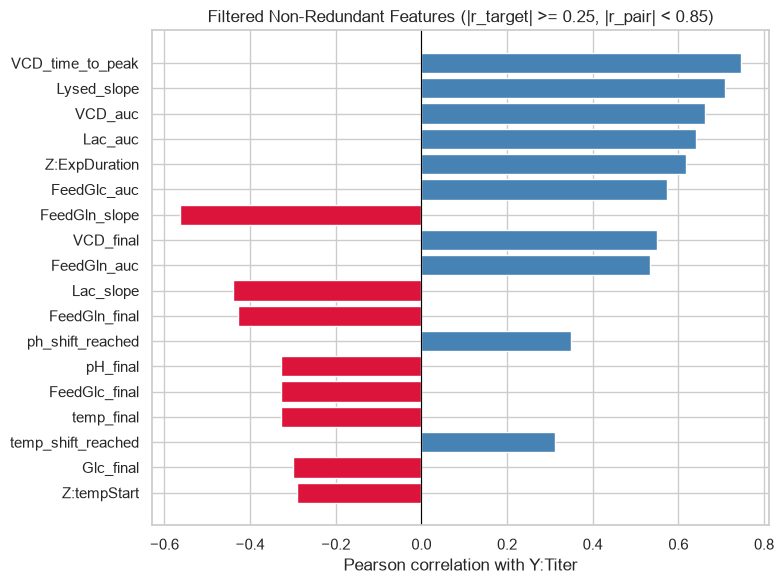

In [22]:
# Correlation-based Feature Filtering Analysis
# Filter 1: Target correlation threshold (|r_target| >= 0.25)
# Filter 2: Pairwise multicollinearity threshold (|r_pair| < 0.85)

target_corr = train_exp[feature_cols].corrwith(train_exp["Y:Titer"])
abs_target_corr = target_corr.abs().sort_values(ascending=False)

min_target_corr = 0.25
candidate_feats = abs_target_corr[abs_target_corr >= min_target_corr].index.tolist()

pair_corr = train_exp[candidate_feats].corr().abs()
max_pair_corr = 0.85

selected_features = []
dropped_features = []

for feat in candidate_feats:
    too_correlated = False
    for s_feat in selected_features:
        if pair_corr.loc[feat, s_feat] >= max_pair_corr:
            too_correlated = True
            dropped_features.append((feat, s_feat, pair_corr.loc[feat, s_feat]))
            break
    if not too_correlated:
        selected_features.append(feat)

print(f"Total features evaluated: {len(feature_cols)}")
print(f"Candidates with |r_target| >= {min_target_corr}: {len(candidate_feats)}")
print(
    f"Retained non-redundant features (|r_pair| < {max_pair_corr}): {len(selected_features)}"
)

retained_df = pd.DataFrame(
    {
        "r_target": target_corr[selected_features],
        "abs_r_target": abs_target_corr[selected_features],
    }
).sort_values("abs_r_target", ascending=False)
print("--- Retained Features ---")
print(retained_df)

if dropped_features:
    dropped_df = pd.DataFrame(
        dropped_features, columns=["Dropped_Feature", "Correlated_With", "Pairwise_r"]
    )
    print("--- Dropped Features (High Multicollinearity) ---")
    print(dropped_df)

# Plot retained features correlation with Y:Titer
plt.figure(figsize=(8, 6))
colors = ["crimson" if target_corr[f] < 0 else "steelblue" for f in retained_df.index]
plt.barh(
    retained_df.index[::-1], target_corr[retained_df.index][::-1], color=colors[::-1]
)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Pearson correlation with Y:Titer")
plt.title(
    f"Filtered Non-Redundant Features (|r_target| >= {min_target_corr}, |r_pair| < {max_pair_corr})"
)
plt.tight_layout()
plt.show()

In [23]:
# Save filtered feature datasets (retained non-redundant features)
filtered_cols = ["n_days"] + selected_features
print(f"{len(filtered_cols)} filtered features to be used:\n")
print(*filtered_cols, sep="\n")

train_exp_filtered = train_exp[filtered_cols + ["Y:Titer"]]
test_exp_filtered = test_exp[filtered_cols]

train_exp_filtered.to_csv(f"{DATA_DIR}/train_exp_features_filtered.csv")
print("\nSaved train_exp_features_filtered.csv:", train_exp_filtered.shape)
test_exp_filtered.to_csv(f"{DATA_DIR}/test_exp_features_filtered.csv")
print("Saved test_exp_features_filtered.csv:", test_exp_filtered.shape)

19 filtered features to be used:

n_days
VCD_time_to_peak
Lysed_slope
VCD_auc
Lac_auc
Z:ExpDuration
FeedGlc_auc
FeedGln_slope
VCD_final
FeedGln_auc
Lac_slope
FeedGln_final
ph_shift_reached
pH_final
FeedGlc_final
temp_final
temp_shift_reached
Glc_final
Z:tempStart

Saved train_exp_features_filtered.csv: (100, 20)
Saved test_exp_features_filtered.csv: (20, 19)


## 4. Baseline modeling & recommendation

See [baseline.ipynb](baseline.ipynb) for baseline model comparison, feature importance analysis, and the modeling recommendation.
